# Data Visualization: Outliers and Distributions

This notebook creates visualizations for:
- Distribution of financial metrics
- Outlier detection and analysis
- Genre performance comparisons
- Temporal trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load the dataset
df = pd.read_csv('data/cleaned/final_merged_dataset_with_genres.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset loaded: 4,197 rows, 113 columns


In [6]:
for c in df.columns:
    print(c)

ticker
date
title
distributor
gross
percent_yd
percent_lw
theaters
per_theater
total_gross
days_in_release
parent company
release_date
year
title_key
weekday
release_month
release_weekday
is_weekend
days_since_release
average_theaters
average_daily_gross
average_daily_gross_per_theater
total_gross_by_average_theaters
avg_gross_monday
avg_gross_tuesday
avg_gross_wednesday
avg_gross_thursday
avg_gross_friday
avg_gross_saturday
avg_gross_sunday
avg_gross_weekend
avg_gross_weekday
gross_per_theater_by_total
weekly_gross_by_total
average_weekly_gross
average_weekly_gross_per_theater
tmdb_id
popularity
imdb_id
original_language
status
budget
revenue
adult
overview
runtime
vote_average
vote_count
origin_country
spoken_languages
genre_ids
genre_names
production_company_ids
production_company_names
belongs_to_collection
omdb_title
omdb_year
omdb_rated
omdb_released
omdb_runtime
omdb_genre
omdb_director
omdb_writer
omdb_actors
omdb_plot
omdb_language
omdb_country
omdb_awards
omdb_poster
omdb_met

## 1. Distribution Analysis

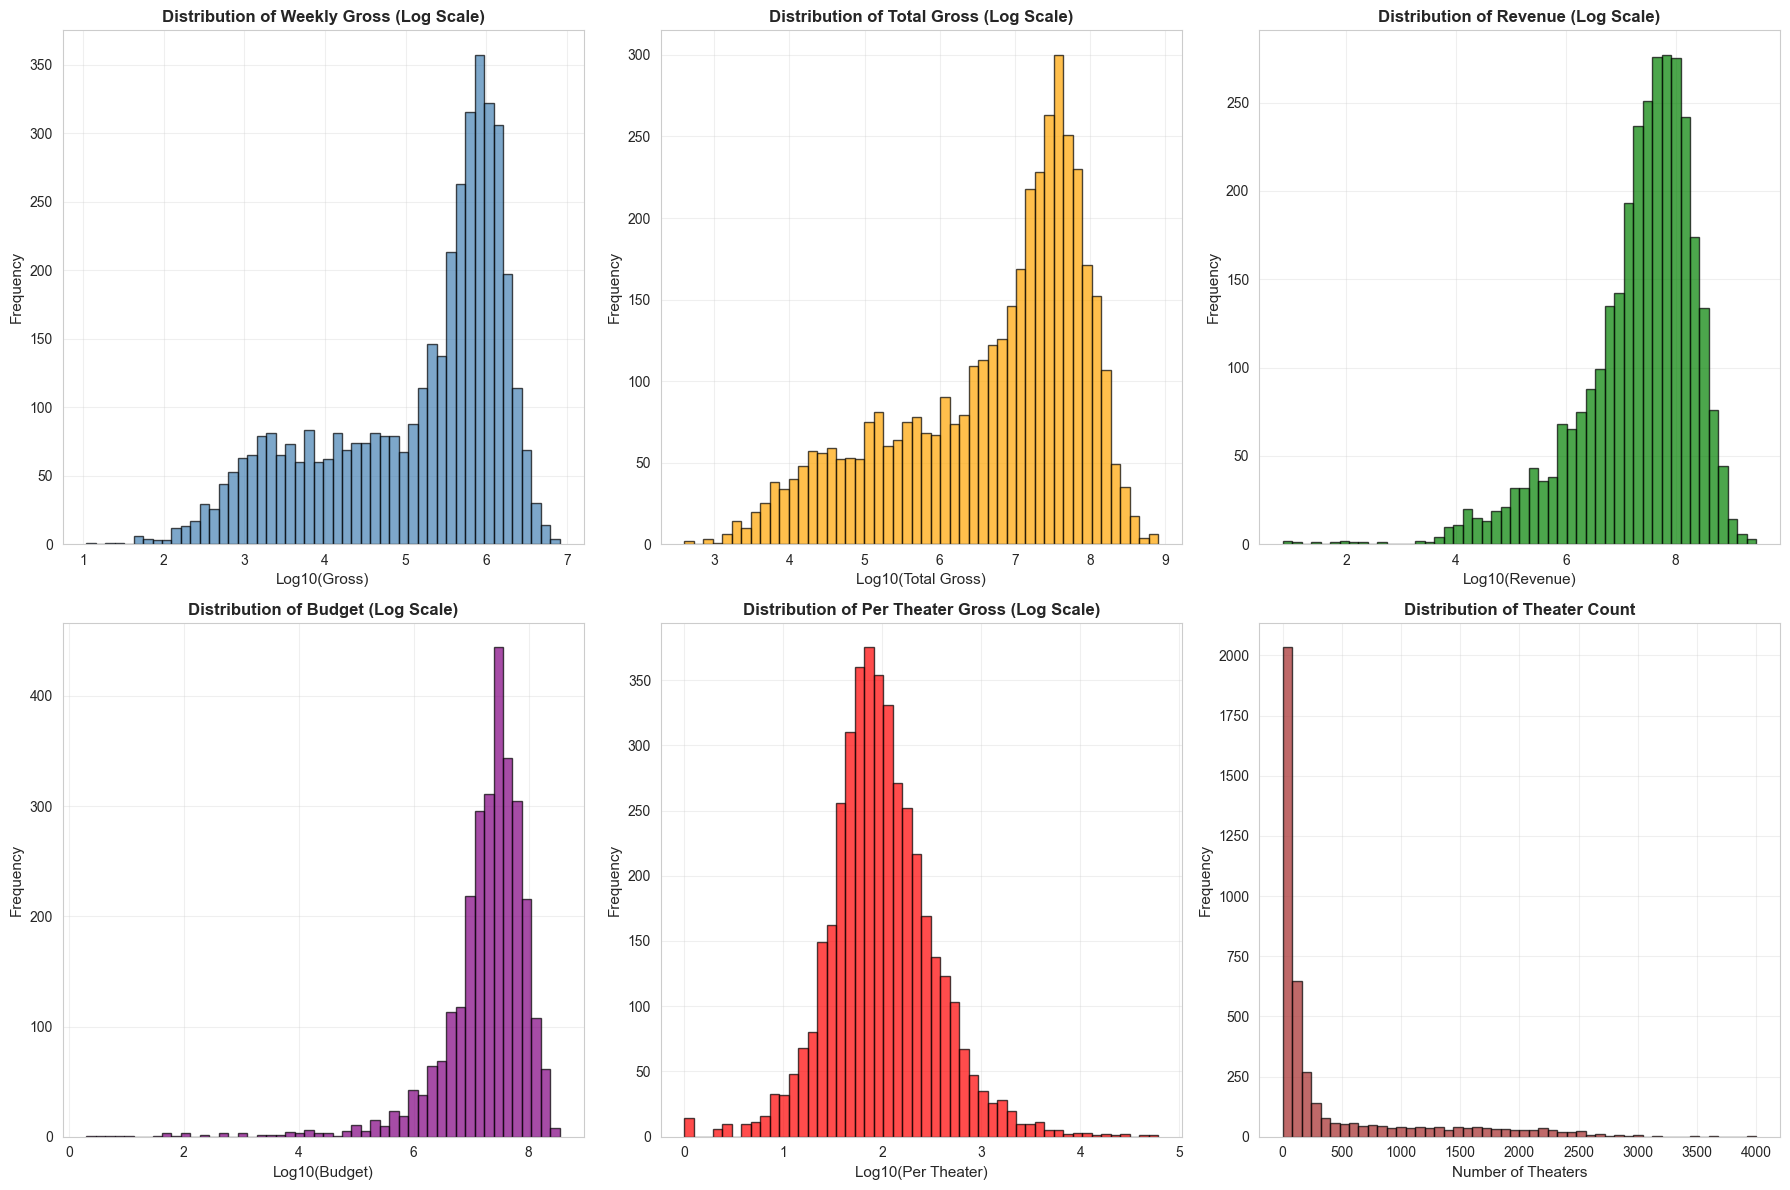

In [3]:
# Create figure with multiple distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Distribution of Gross (Log Scale)
gross_nonzero = df[df['average_daily_gross'] > 0]['average_daily_gross']
axes[0, 0].hist(np.log10(gross_nonzero), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Log10(Gross)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Weekly Gross (Log Scale)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution of Total Gross (Log Scale)
total_gross_nonzero = df[df['total_gross'] > 0]['total_gross']
axes[0, 1].hist(np.log10(total_gross_nonzero), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Log10(Total Gross)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Total Gross (Log Scale)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of Revenue (Log Scale)
revenue_nonzero = df[df['revenue'] > 0]['revenue']
axes[0, 2].hist(np.log10(revenue_nonzero), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_xlabel('Log10(Revenue)', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title('Distribution of Revenue (Log Scale)', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. Distribution of Budget (Log Scale)
budget_nonzero = df[df['budget'] > 0]['budget']
axes[1, 0].hist(np.log10(budget_nonzero), bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_xlabel('Log10(Budget)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of Budget (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 5. Distribution of Per Theater (Log Scale)
per_theater_nonzero = df[df['per_theater'] > 0]['per_theater']
axes[1, 1].hist(np.log10(per_theater_nonzero), bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Log10(Per Theater)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Per Theater Gross (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 6. Distribution of Theaters
theaters_nonzero = df[df['theaters'] > 0]['theaters']
axes[1, 2].hist(theaters_nonzero, bins=50, edgecolor='black', alpha=0.7, color='brown')
axes[1, 2].set_xlabel('Number of Theaters', fontsize=11)
axes[1, 2].set_ylabel('Frequency', fontsize=11)
axes[1, 2].set_title('Distribution of Theater Count', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Outlier Analysis with Box Plots

average_daily_gross_adjusted_2024
average_daily_gross_per_theater_adjusted_2024
gross_per_theater_by_total_adjusted_2024
average_weekly_gross_adjusted_2024
average_weekly_gross_per_theater_adjusted_2024

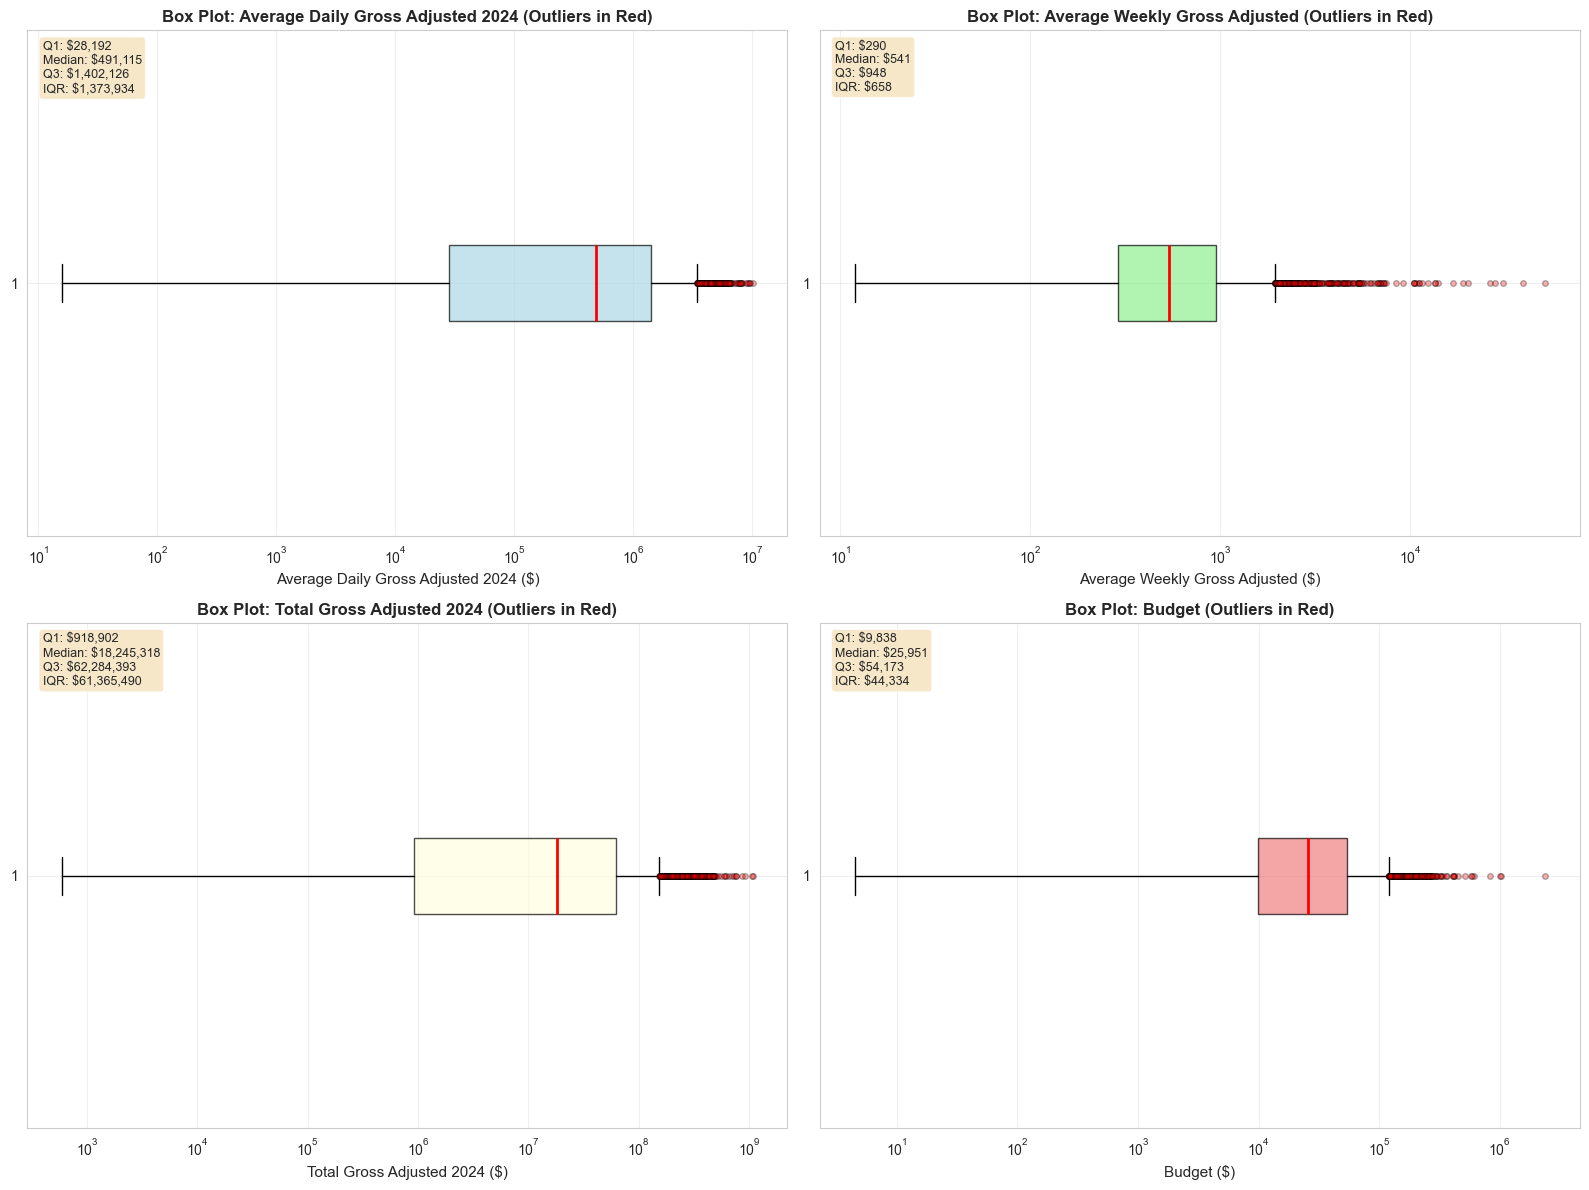

In [8]:
# Create box plots for outlier detection
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

columns_to_plot = ['average_daily_gross_adjusted_2024', 'average_daily_gross_per_theater_adjusted_2024', 'total_gross_adjusted_2024', 'gross_per_theater_by_total_adjusted_2024', 'budget'
, 'average_weekly_gross_adjusted_2024', 'average_weekly_gross_per_theater_adjusted_2024', 'total_gross_adjusted_2024', 'gross_per_theater_by_total_adjusted_2024', 'budget']
titles = ['Average Daily Gross Adjusted 2024', 'Average Weekly Gross Adjusted', 'Total Gross Adjusted 2024', 'Budget']
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

for idx, (col, title, color) in enumerate(zip(columns_to_plot, titles, colors)):
    ax = axes[idx // 2, idx % 2]
    data_nonzero = df[df[col] > 0][col]

    # Create box plot
    bp = ax.boxplot(data_nonzero, vert=False, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.3))

    ax.set_xlabel(f'{title} ($)', fontsize=11)
    ax.set_title(f'Box Plot: {title} (Outliers in Red)', fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

    # Add statistics
    Q1 = data_nonzero.quantile(0.25)
    Q3 = data_nonzero.quantile(0.75)
    median = data_nonzero.median()
    IQR = Q3 - Q1

    stats_text = f'Q1: ${Q1:,.0f}\nMedian: ${median:,.0f}\nQ3: ${Q3:,.0f}\nIQR: ${IQR:,.0f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
            fontsize=9)

plt.tight_layout()
plt.show()

## 3. Budget vs Revenue Analysis

In [ ]:
# Scatter plot: Budget vs Revenue
fig, ax = plt.subplots(figsize=(12, 8))

df_both = df[(df['budget'] > 0) & (df['revenue'] > 0)]

scatter = ax.scatter(df_both['budget'], df_both['revenue'], 
                    alpha=0.4, s=30, c=df_both['year'],
                    cmap='viridis', edgecolors='black', linewidth=0.3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Budget ($, Log Scale)', fontsize=12)
ax.set_ylabel('Revenue ($, Log Scale)', fontsize=12)
ax.set_title('Budget vs Revenue (colored by year)', fontsize=14, fontweight='bold')

# Add diagonal line for break-even
min_val = min(df_both['budget'].min(), df_both['revenue'].min())
max_val = max(df_both['budget'].max(), df_both['revenue'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, linewidth=2, label='Break-even')

ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year', fontsize=11)

plt.tight_layout()
plt.show()

# Calculate ROI statistics
df_both['roi'] = (df_both['revenue'] - df_both['budget']) / df_both['budget'] * 100
print(f"\nROI Statistics:")
print(f"  Mean ROI: {df_both['roi'].mean():.1f}%")
print(f"  Median ROI: {df_both['roi'].median():.1f}%")
print(f"  Movies that made profit (revenue > budget): {(df_both['revenue'] > df_both['budget']).sum():,} ({(df_both['revenue'] > df_both['budget']).sum()/len(df_both)*100:.1f}%)")

## 4. Total Gross vs Revenue Comparison

In [ ]:
# Detailed scatter plot for gross vs revenue
fig, ax = plt.subplots(figsize=(12, 8))

df_valid = df[(df['total_gross'] > 0) & (df['revenue'] > 0)]

scatter = ax.scatter(df_valid['total_gross'], df_valid['revenue'],
                    alpha=0.5, s=30, c=df_valid['year'],
                    cmap='plasma', edgecolors='black', linewidth=0.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Total Gross ($, Log Scale)', fontsize=12)
ax.set_ylabel('Revenue ($, Log Scale)', fontsize=12)
ax.set_title('Total Gross vs Revenue (colored by year)', fontsize=14, fontweight='bold')

# Add diagonal line for total_gross = revenue
min_val = min(df_valid['total_gross'].min(), df_valid['revenue'].min())
max_val = max(df_valid['total_gross'].max(), df_valid['revenue'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, linewidth=2, label='Total Gross = Revenue')

ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Genre Analysis Visualizations

In [ ]:
# Genre performance comparison
genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 'documentary',
                 'drama', 'family', 'fantasy', 'history', 'horror', 'music', 'mystery',
                 'romance', 'science_fiction', 'thriller', 'tv_movie', 'war', 'western']

# Calculate average gross by genre
genre_avg_gross = {}
genre_median_gross = {}
genre_counts = {}

for genre in genre_columns:
    if genre in df.columns:
        genre_movies = df[df[genre] == 1]
        genre_with_gross = genre_movies[genre_movies['gross_adjusted_2024'] > 0]
        if len(genre_with_gross) > 0:
            genre_avg_gross[genre] = genre_with_gross['gross_adjusted_2024'].mean()
            genre_median_gross[genre] = genre_with_gross['gross_adjusted_2024'].median()
            genre_counts[genre] = len(genre_with_gross)

# Sort by average gross
genre_avg_sorted = dict(sorted(genre_avg_gross.items(), key=lambda x: x[1], reverse=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Average gross by genre
genres = list(genre_avg_sorted.keys())
avg_gross = list(genre_avg_sorted.values())

ax1.barh(genres, avg_gross, color='coral', alpha=0.8)
ax1.set_xlabel('Average Gross Adjusted 2024 ($)', fontsize=12)
ax1.set_ylabel('Genre', fontsize=12)
ax1.set_title('Average Gross by Genre (Inflation Adjusted)', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

for i, v in enumerate(avg_gross):
    ax1.text(v + 1500, i, f'${v:,.0f}', va='center', fontsize=9)

# Median gross by genre
median_gross = [genre_median_gross[g] for g in genres]

ax2.barh(genres, median_gross, color='steelblue', alpha=0.8)
ax2.set_xlabel('Median Gross Adjusted 2024 ($)', fontsize=12)
ax2.set_ylabel('Genre', fontsize=12)
ax2.set_title('Median Gross by Genre (Inflation Adjusted)', fontsize=13, fontweight='bold')
ax2.invert_yaxis()

for i, v in enumerate(median_gross):
    ax2.text(v + 200, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Distributor Performance

In [ ]:
# Box plot: Gross by Top Distributors
fig, ax = plt.subplots(figsize=(14, 8))

top_distributors = df['distributor'].value_counts().head(10).index
df_top_dist = df[df['distributor'].isin(top_distributors)]
df_top_dist_nonzero = df_top_dist[df_top_dist['gross_adjusted_2024'] > 0]

# Create box plot
bp = df_top_dist_nonzero.boxplot(column='gross_adjusted_2024', by='distributor', 
                                  ax=ax, figsize=(14, 8), rot=45)

ax.set_yscale('log')
ax.set_xlabel('Distributor', fontsize=12)
ax.set_ylabel('Gross Adjusted 2024 (Log Scale)', fontsize=12)
ax.set_title('Gross Distribution by Top 10 Distributors', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove the automatic title

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Temporal Trends

In [ ]:
# Time series analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Movies per year
year_counts = df['year'].value_counts().sort_index()
axes[0, 0].plot(year_counts.index, year_counts.values, marker='o', linewidth=2, markersize=4, color='steelblue')
axes[0, 0].set_xlabel('Year', fontsize=11)
axes[0, 0].set_ylabel('Number of Movies', fontsize=11)
axes[0, 0].set_title('Movies Released per Year', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average gross by year
avg_gross_by_year = df.groupby('year')['gross_adjusted_2024'].mean()
axes[0, 1].plot(avg_gross_by_year.index, avg_gross_by_year.values, marker='o', linewidth=2, markersize=4, color='coral')
axes[0, 1].set_xlabel('Year', fontsize=11)
axes[0, 1].set_ylabel('Average Gross Adjusted 2024', fontsize=11)
axes[0, 1].set_title('Average Gross per Movie by Year', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Average theaters by year
avg_theaters_by_year = df.groupby('year')['theaters'].mean()
axes[1, 0].plot(avg_theaters_by_year.index, avg_theaters_by_year.values, marker='o', linewidth=2, markersize=4, color='green')
axes[1, 0].set_xlabel('Year', fontsize=11)
axes[1, 0].set_ylabel('Average Number of Theaters', fontsize=11)
axes[1, 0].set_title('Average Theater Count by Year', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Total revenue by year
total_revenue_by_year = df[df['revenue'] > 0].groupby('year')['revenue'].sum()
axes[1, 1].bar(total_revenue_by_year.index, total_revenue_by_year.values, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Year', fontsize=11)
axes[1, 1].set_ylabel('Total Revenue', fontsize=11)
axes[1, 1].set_title('Total Revenue by Year', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

In [ ]:
# Correlation heatmap - Financial columns
fig, ax = plt.subplots(figsize=(10, 8))

financial_cols = ['gross', 'total_gross', 'revenue', 'budget', 'theaters', 'per_theater']
corr_matrix = df[financial_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=ax, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)

ax.set_title('Correlation Matrix - Financial Metrics', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()